In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Libreria de Tratamiento de Datos
from IPython.display import display

# Exploracion de Archivos
import sys
sys.path.append('../') # para que busque en carpeta src 
from src import sp_eda as se
from src import sp_carga_integracion as ci

# Funcion personalizada para asegurarnos que aparezcan todas las columnas
pd.set_option('display.max_columns', None) 

In [3]:
df = pd.read_csv(
    "../data/processed/02_datos_limpios.csv",
    parse_dates=['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro']
)

In [4]:
ci.eda_preliminar(df)

5 FILAS ALEATORIAS


,669,41325,22215,18574,36738
order_id,670,41326,22216,18575,36739
id_cliente,b24dce72-00b3-48fd-bb59-6f591cb5b9f2,cc01365f-7f9b-445c-97fd-2372883916ec,96770516-1e8d-4086-9416-5a6a5070c0a0,593a4802-d958-408a-bdfc-f0da39b9bf81,68b60335-84a0-4062-8945-06a51e616f24
product_id,P0082,P0035,P0070,P0077,P0052
fecha_pedido,2022-10-01 00:00:00,2025-01-19 00:00:00,2023-09-25 00:00:00,2023-02-18 00:00:00,2024-04-08 00:00:00
cantidad,1,3,1,2,1
precio_unitario,28.32,46.26,60.85,46.15,85.8
descuento,0.15,0.15,0.0,0.05,0.1
importe_total,24.07,117.98,60.85,87.68,77.22
metodo_pago,tarjeta de credito,transferencia,transferencia,tarjeta de debito,transferencia
envio_gratis,no,no,no,no,no


DIMENSIONES
El munero de filas es: 52000 filas 
El munero de columnas es: 39 columnas
INFORMACION BASICA
<class 'pandas.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  52000 non-null  int64         
 1   id_cliente                52000 non-null  str           
 2   product_id                52000 non-null  str           
 3   fecha_pedido              52000 non-null  datetime64[us]
 4   cantidad                  52000 non-null  int64         
 5   precio_unitario           52000 non-null  float64       
 6   descuento                 52000 non-null  float64       
 7   importe_total             52000 non-null  float64       
 8   metodo_pago               52000 non-null  str           
 9   envio_gratis              52000 non-null  str           
 10  calificacion              52000 non-null  float6

,count,unique,top,freq
id_cliente,52000,7987,f9d54acf-ff02-4eda-a470-4e10a762f16a,20
product_id,52000,90,P0003,678
metodo_pago,52000,6,tarjeta de credito,17964
envio_gratis,52000,2,no,36333
devuelto,52000,2,no,48941
canal,52000,4,web,20887
categoria_producto,52000,5,electronica,10596
nombre_producto,52000,90,Auriculares Nova Max,678
marca,52000,9,vantia,10898
proveedor,52000,4,norte logistica,15098


ESTADISTICOS NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
order_id,52000.0,26000.500000,15011.251336,1.000,13000.7500,26000.500,39000.250,52000.0000
cantidad,52000.0,2.047192,1.201054,1.000,1.0000,2.000,3.000,5.0000
precio_unitario,52000.0,56.444597,56.314990,5.090,29.2175,47.130,72.620,4522.2800
descuento,52000.0,0.070436,0.076881,0.000,0.0000,0.050,0.100,0.3000
importe_total,52000.0,107.285283,137.827908,4.220,40.0200,72.520,133.940,11531.8200
calificacion,52000.0,4.044654,0.967026,1.000,4.0000,4.000,5.000,5.0000
año_ventas,52000.0,2023.500000,1.118045,2022.000,2022.7500,2023.500,2024.250,2025.0000
costo_unitario,52000.0,32.404215,20.454381,5.240,17.0000,26.730,42.030,96.1500
precio_lista,52000.0,56.905882,37.449707,9.700,31.0700,45.860,77.930,211.3600
peso_kg,52000.0,6.216765,3.513158,0.300,2.9500,6.890,9.280,11.9800


In [5]:
clientes = df.groupby('id_cliente').agg(
    n_pedidos=('order_id', 'count'),
    gasto_total=('importe_total', 'sum'),
    edad=('edad', 'first'),
    ciudad=('ciudad', 'first'),
    segmento_cliente=('segmento_cliente', 'first'),
    ingresos_anuales=('ingresos_anuales', 'first'),
).reset_index()
clientes

,id_cliente,n_pedidos,gasto_total,edad,ciudad,segmento_cliente,ingresos_anuales
0,00047a8c-eaed-4e09-a302-4081b07e37f9,6,582.25,44.0,barcelona,corporativo,41626
1,0005530b-bb59-4862-9ed1-9ba4b57e4b95,8,714.03,64.0,granada,recurrente,64957
2,000c848f-a5fc-40a5-a3ba-3de5a7e12089,1,9.49,40.0,sevilla,nuevo,37981
3,0013343e-3a60-417d-bad5-88780f5a83a1,4,520.32,34.0,murcia,corporativo,61224
4,0030dae9-1d2a-4aaf-ba17-c19d34228fbc,3,193.17,48.0,vigo,recurrente,24208
...,...,...,...,...,...,...,...
7982,ffe3fcfa-07c0-42c4-b97c-52ab6efac87a,1,110.87,22.0,vigo,nuevo,72177
7983,ffe5e4a4-9512-4bbd-98f9-75a00a28f4ce,5,648.41,31.0,zaragoza,nuevo,38826
7984,ffea67ee-8438-441c-b8a0-5c0ff886b034,3,175.72,47.0,sevilla,nuevo,35518
7985,fff01d47-aae0-4ce5-847d-aea0a915c59d,9,546.42,35.0,malaga,recurrente,30258


#### 1. PRE-EDA ####


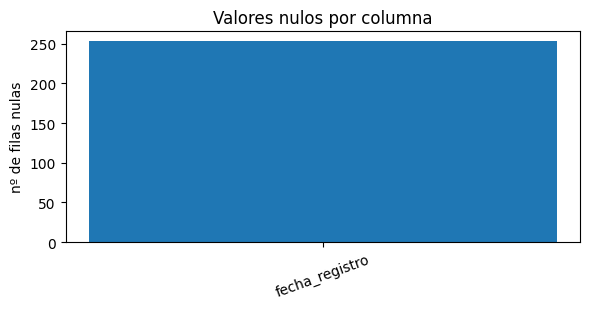

Columnas con nulos: 1 de 39
fecha_registro    253
dtype: int64

order_id duplicados: 0  (esperado: 0)
id_cliente duplicados: 44013  (>0 es normal: varios pedidos por cliente)
id_cliente únicos: 7987


In [6]:
print('#### 1. PRE-EDA ####')
se.pre_eda_calidad(df)


In [7]:
cols_excluir = ['order_id', 'id_cliente', 'product_id', 'nombre_producto',
                 'latitude', 'longitude']


In [8]:
se.cols_categoricas_validas(df,excluir=cols_excluir)

COLUMNAS CATEGORICA VALIDAS


['metodo_pago',
 'envio_gratis',
 'devuelto',
 'canal',
 'categoria_producto',
 'marca',
 'proveedor',
 'estado_civil',
 'nivel_educativo',
 'tiene_hijos',
 'adolescentes_en_casa',
 'ciudad',
 'region',
 'segmento_cliente']

In [9]:
se.cols_numericas_validas(df,excluir=cols_excluir)

COLUMNAS NUMERICAS VALIDAS


['cantidad',
 'precio_unitario',
 'descuento',
 'importe_total',
 'calificacion',
 'costo_unitario',
 'precio_lista',
 'peso_kg',
 'stock_disponible',
 'rating_promedio_producto',
 'edad',
 'ingresos_anuales',
 'visitas_web_mes',
 'precio_unitario_wz',
 'importe_total_wz']

COLUMNAS CATEGORICA VALIDAS


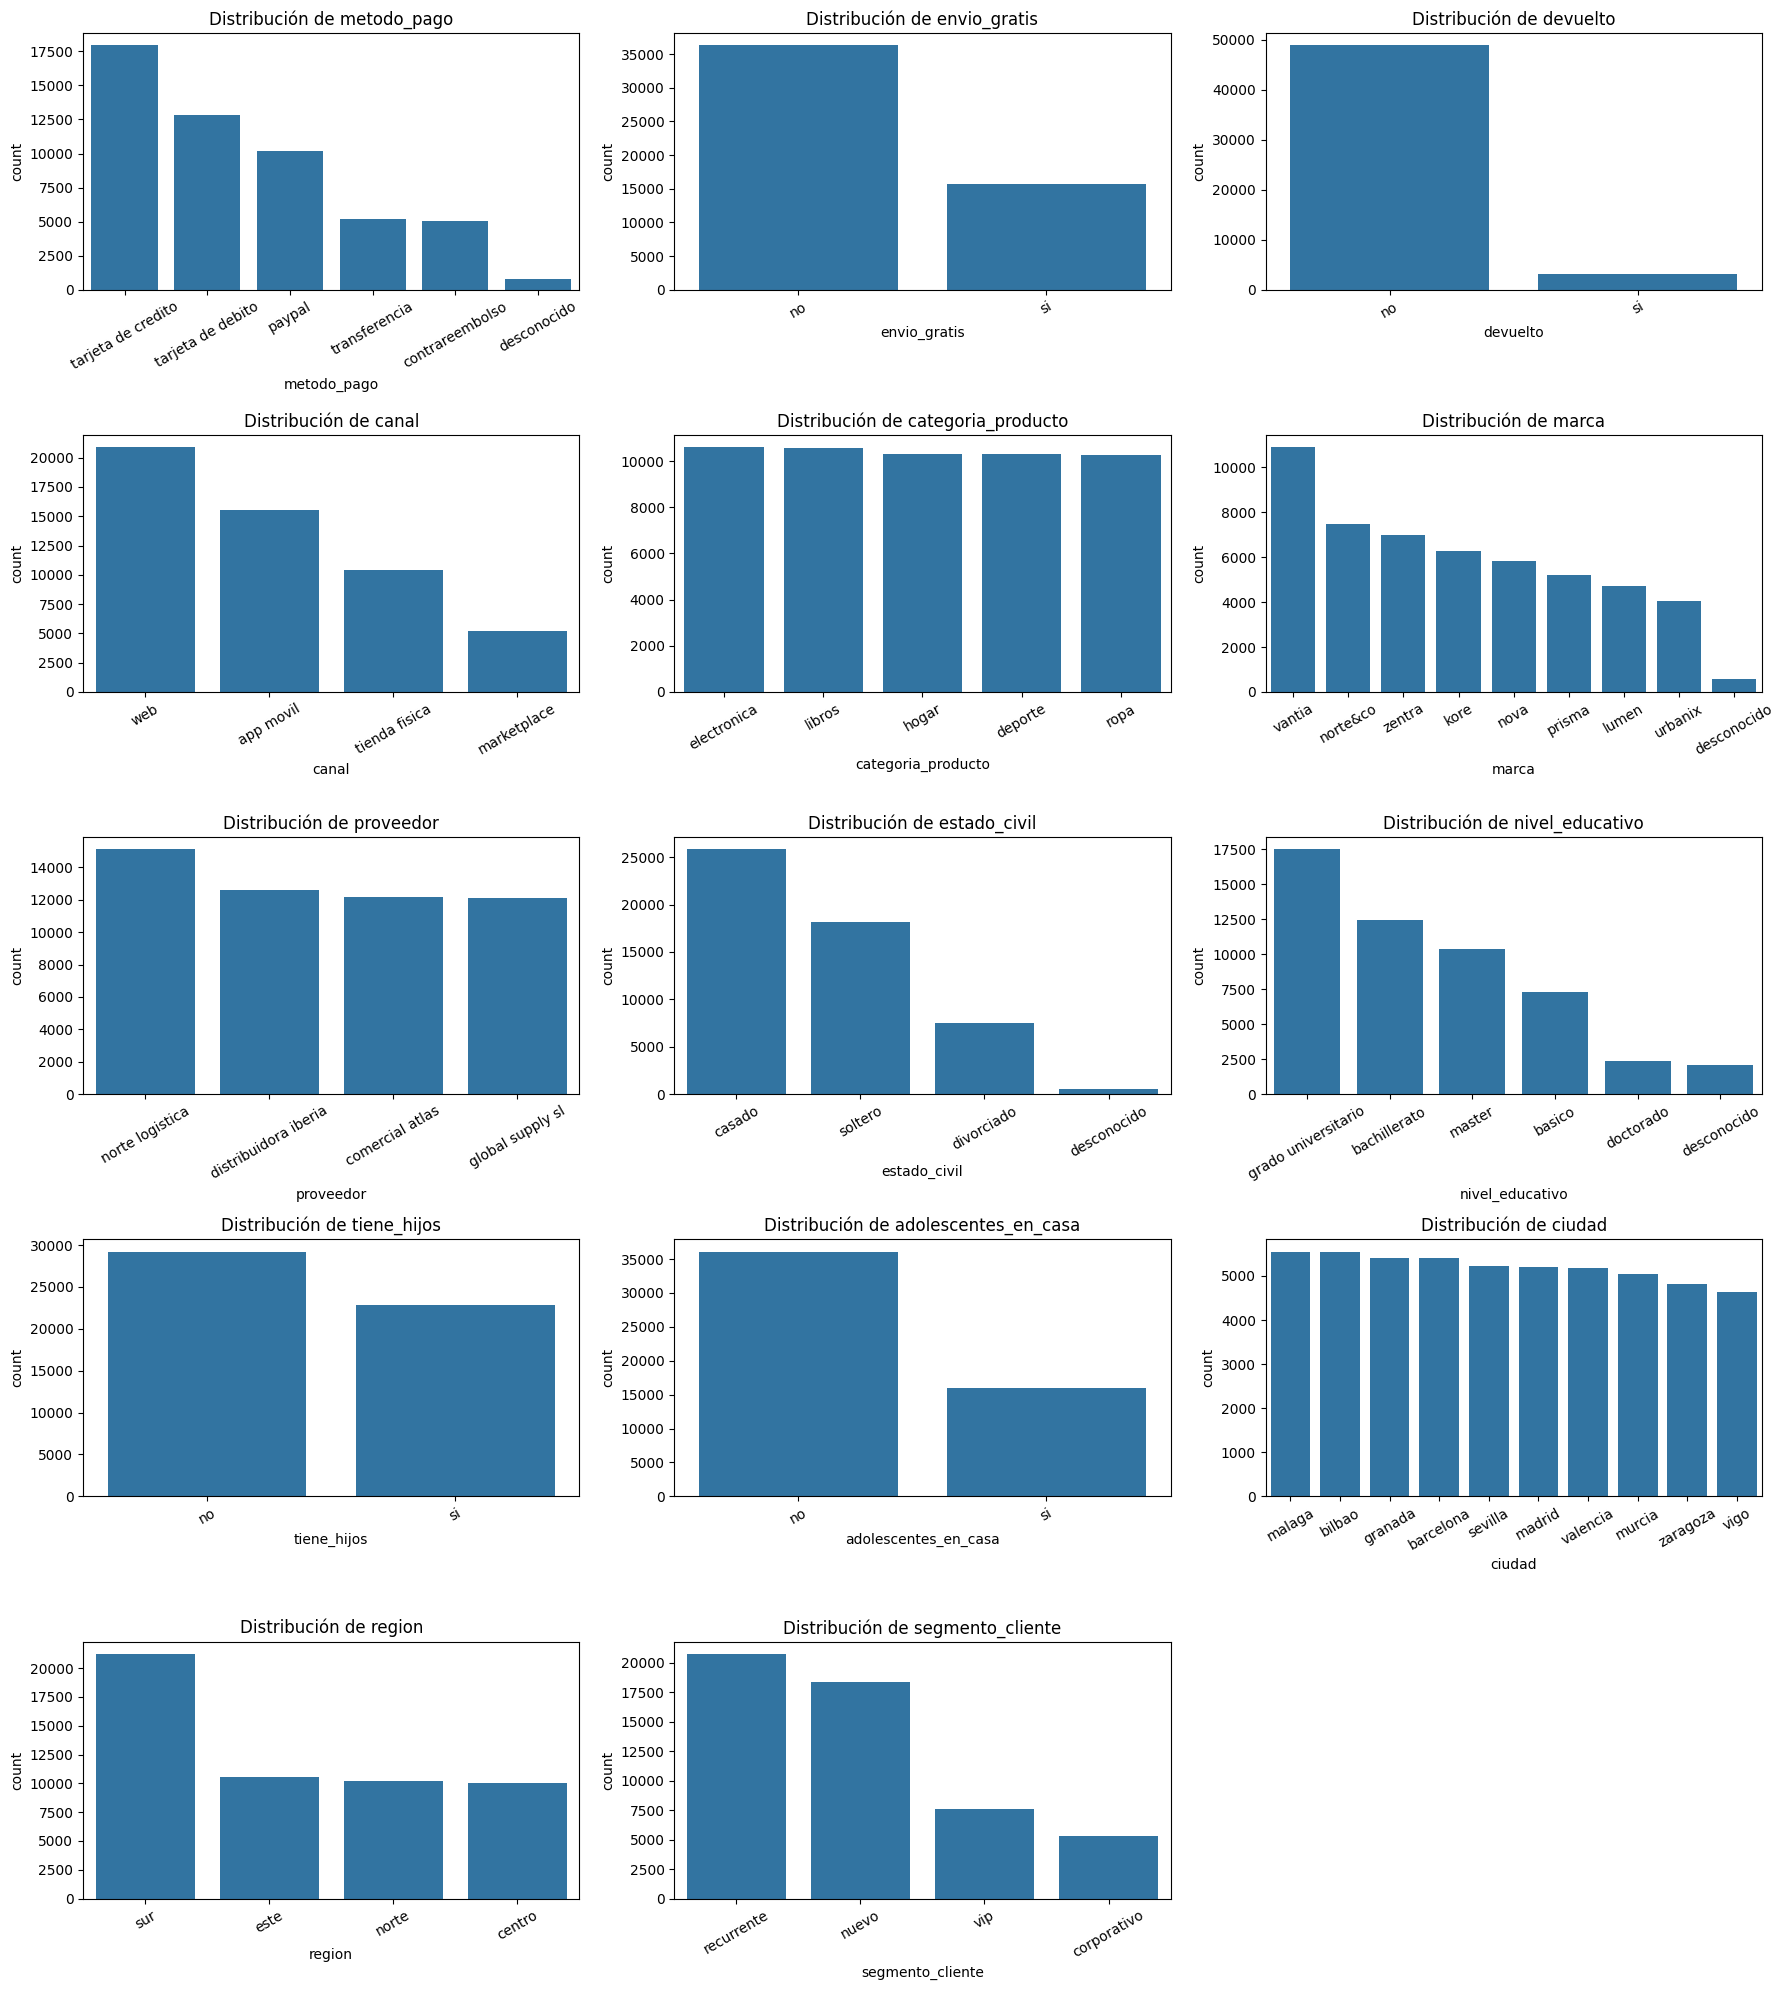

In [10]:
se.univariante_categorico(df)

COLUMNAS NUMERICAS VALIDAS


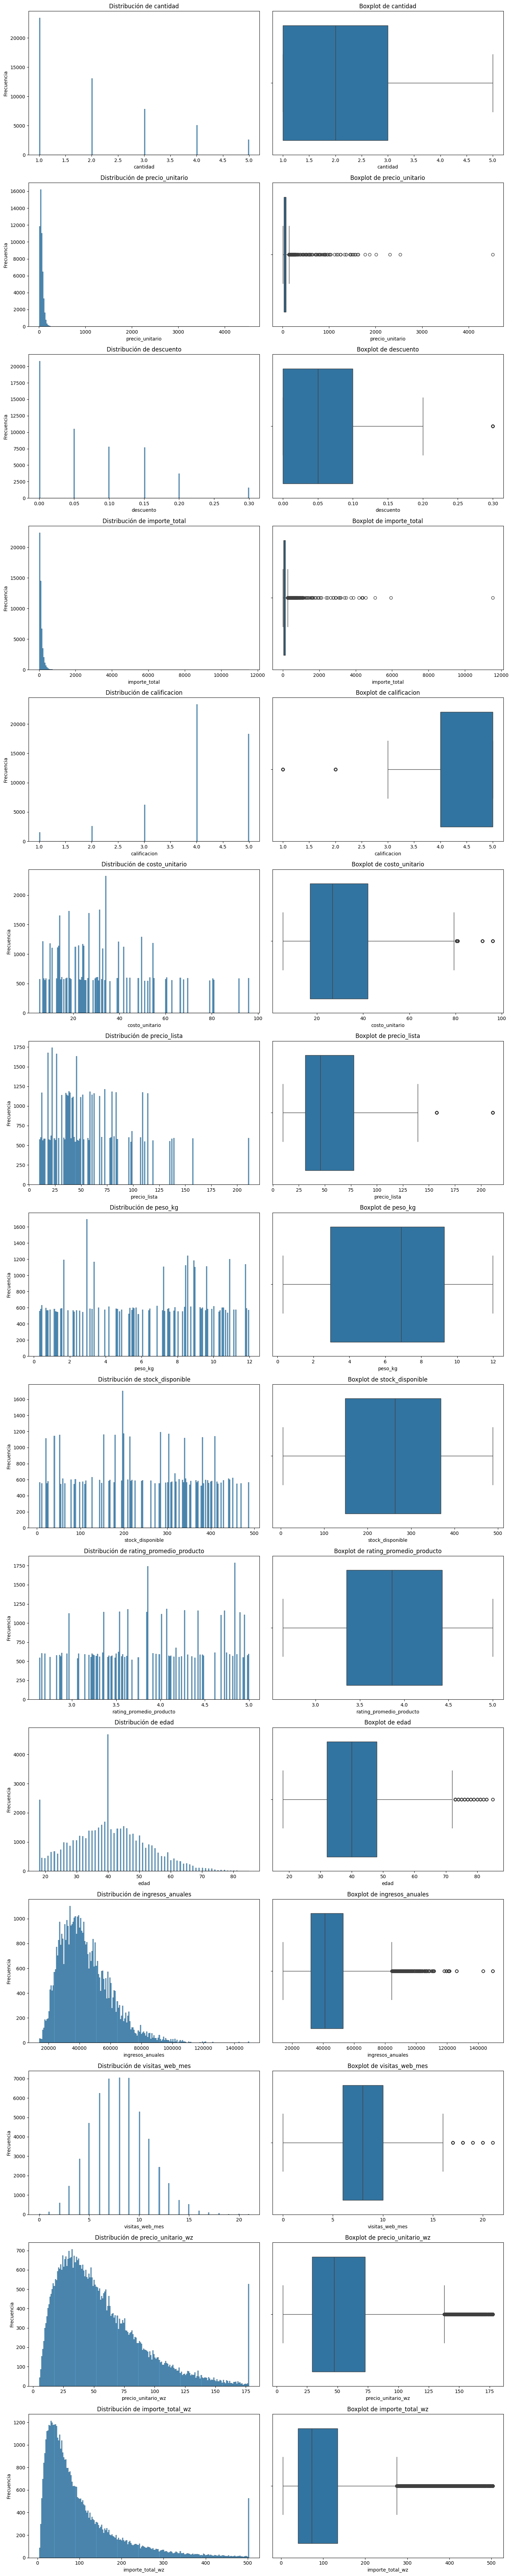

In [11]:
se.univariante_numerico(df, excluir=cols_excluir)

In [12]:
resumen = se.resumen_numerico(df, excluir=cols_excluir)
resumen

COLUMNAS NUMERICAS VALIDAS


,media,mediana,outliers_pct,skew
cantidad,2.047192,2.00,0.00,0.95
precio_unitario,56.444597,47.13,3.22,21.78
descuento,0.070436,0.05,3.01,1.00
importe_total,107.285283,72.52,6.55,20.65
calificacion,4.044654,4.00,7.90,-1.21
costo_unitario,32.404215,26.73,4.47,1.08
precio_lista,56.905882,45.86,2.27,1.38
peso_kg,6.216765,6.89,0.00,-0.14
stock_disponible,250.003231,263.00,0.00,-0.19
rating_promedio_producto,3.875764,3.86,0.00,0.03


El código:
df[col].skew()
mide la asimetría.
De forma simplificada:

skew ≈ 0
→ distribución relativamente simétrica

skew > 0
→ cola hacia valores altos

skew < 0
→ cola hacia valores bajos
